This Python Notebook creates, validates, and tests the RL environment CarboNet using the Stable-Baselines3 library [1]. The model derives from mass balances and is a thermodynamical material network with 15 compartments [2], [3]. The model equations are given in [4], while the reward function is given in [5]. The ordinary differential equations are solved numerically using the Euler's method [6].

### References
[1] Stable-Baselines3 (SB3) documentation: https://stable-baselines3.readthedocs.io/en/master/

[2] Zocco, F., Sopasakis, P., Smyth, B. and Haddad, W.M., 2023. Thermodynamical material networks for modeling, planning, and control of circular material flows. International Journal of Sustainable Engineering, 16(1), pp. 1-14.

[3] Zocco, F., Haddad, W.M., Corti, A. and Malvezzi, M., 2024. A unification between deep-learning vision, compartmental dynamical thermodynamics, and robotic manipulation for a circular economy. IEEE Access, pp. 173502-173516.

[4] Zocco, F., Haddad, W.M. and Malvezzi, M., 2025. CarboNet: A finite-time combustion-tolerant compartmental network for tropospheric carbon control. arXiv preprint arXiv:2508.16774.

[5] Zocco, F., Corti, A. and Malvezzi, M., 2025. CiRL: Open-source environments for reinforcement learning in circular economy and net zero. arXiv preprint arXiv:2505.21536.

[6] Euler's method for approximating the solution of ordinary differential equations: https://tutorial.math.lamar.edu/classes/de/eulersmethod.aspx


### Other Useful Reading
* Creating custom environment with SB3: https://stable-baselines3.readthedocs.io/en/master/guide/custom_env.html  

* Practical advices for creating custom environments with SB3: https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html#tips-and-tricks-when-creating-a-custom-environment

* To create this environment, I also followed the structure of the pendulum environment: https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/classic_control/pendulum.py

* Documentation of the pendulum environment: https://gymnasium.farama.org/environments/classic_control/pendulum/

* Formula for normalizing/de-normalizing the action space: https://stats.stackexchange.com/questions/281162/scale-a-number-between-a-range  

* How to implement the normalization/de-normalization of the action space: https://github.com/hill-a/stable-baselines/issues/678

In [ ]:
!pip install "stable-baselines3[extra]>=2.0.0a4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 6.4 MB/s eta 0:00:00


Creation of the environment class with its constituent functions:

In [ ]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from gymnasium import spaces

"""
This environment is CarboNet [1]. It is in the state-space form and consists of four first-order linear ordinary differential equations. Carbon dioxide is produced by
vehicles and house heaters, it enters the atmosphere and, simultaneously, is removed by a carbon-capture system. This network is made of 15 thermodynamic compartments
(compartmental networks were formulated in [2]).

Action: u (CO_2 per day absorbed by the carbon-capture system)
States/observations: x1, x2, x3, x4

References:
[1] Zocco, F., Haddad, W.M. and Malvezzi, M., 2025. CarboNet: A Finite-Time Combustion-Tolerant Compartmental Network for Tropospheric
Carbon Control. arXiv preprint arXiv:2508.16774.
[2] Zocco, F., Sopasakis, P., Smyth, B. and Haddad, W.M., 2023. Thermodynamical material networks for modeling, planning, and control of circular material flows.
International Journal of Sustainable Engineering, 16(1), pp.1-14.
"""

# Initial conditions:
x1_ini = 915.4
x2_ini = 210.0
x3_ini = 500.0
x4_ini = 1830.8


class CarboNet(gym.Env):

    # Because of google colab, we cannot implement the GUI ('human' render mode)
    metadata = {"render_modes": ["console"]}



    def __init__(self, render_mode="console"):
        super(CarboNet, self).__init__()
        self.render_mode = render_mode

        # Integration step size:
        self.dt = 0.00005

        # Model parameters:
        # For eq. 1:
        self.a_41 = 0.2
        self.a_14 = 0.1
        self.n_h = 10000
        self.a_13 = 0.5/self.n_h
        self.n_q = 5000
        self.a_12 = 0.5/self.n_q
        # For eq. 2:
        self.a_22 = 0.3
        self.a_42 = 0.5/self.n_q
        # For eq. 3:
        self.a_33 = 0.6
        self.a_43 = 0.5/self.n_h
        # For eq. 4:
        # no further parameters
        # Min and max of actions:
        self.u_min = 0
        self.u_max = 10**6
        # Min and max of states:
        self.x1_min = 0
        self.x1_max = np.inf
        self.x2_min = 0
        self.x2_max = np.inf
        self.x3_min = 0
        self.x3_max = np.inf
        self.x4_min = 0
        self.x4_max = np.inf


        # Parameters for reward function:
        self.x1_desired = 637.2 # [t]

        # Define action and observation space with limits:
        min_values = np.array([self.x1_min, self.x2_min, self.x3_min, self.x4_min], dtype=np.float32)
        max_values = np.array([self.x1_max, self.x2_max, self.x3_max, self.x4_max], dtype=np.float32)
        self.action_space = spaces.Box(
            low=-1, high=1, shape=(1,), dtype=np.float32
        ) # normalized between [-1, 1] as suggested in https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html

        self.observation_space = spaces.Box(low=min_values, high=max_values, dtype=np.float32)


    def step(self, u):  #u is the action

      x1, x2, x3, x4 = self.state

      dt = self.dt
      a_41 = self.a_41
      a_14 = self.a_14
      n_h = self.n_h
      a_13 = self.a_13
      n_q = self.n_q
      a_12 = self.a_12
      a_22 = self.a_22
      a_42 = self.a_42
      a_33 = self.a_33
      a_43 = self.a_43
      x1_desired = self.x1_desired
      u_min = self.u_min
      u_max = self.u_max

      # Clip and re-scale the action from [-1, 1] to [u_min, u_max] before the state-space equations:
      u = np.clip(u, -1, 1)[0] # convert 1-dim vector into scalar
      u = ((u-(-1))/(1-(-1)))*(u_max-u_min)+u_min # (general formula: https://stats.stackexchange.com/questions/281162/scale-a-number-between-a-range)

      # State-space equations:
      x1_dot = - a_41*x1 + a_14*x4 + n_h*a_13*x3 + n_q*a_12*x2 - u #first state equation
      x2_dot = a_22*x2 - n_q*a_12*x2 - n_q*a_42*x2 #second state equation
      x3_dot = a_33*x3 - n_h*a_13*x3 - n_h*a_43*x3 #third state equation
      x4_dot = a_41*x1 - a_14*x4 + n_q*a_42*x2 + n_h*a_43*x3 #fourth state equation

      # Update the states using Euler's method (approximation):
      x1 = x1 + x1_dot*dt
      x2 = x2 + x2_dot*dt
      x3 = x3 + x3_dot*dt
      x4 = x4 + x4_dot*dt

      # Reward, termination and truncation conditions:
      reward = - (x1_desired - x1)**2
      truncated = False # we do not limit the number of steps here, but in model.learn()
      terminated = False

      # Update the state:
      self.state = np.array([x1, x2, x3, x4])
      obs = self.state

      # Optionally we can pass additional info:
      info = {"u (action)": u}

      return obs.astype(np.float32), float(reward), truncated, terminated, info


    def reset(self, seed=None, options=None):
        """
        Important: the observation must be a numpy array
        :return: (np.array)
        """
        super().reset(seed=seed, options=options)
        self.state = np.array([x1_ini, x2_ini, x3_ini, x4_ini], dtype=np.float32)

        return self.state, {}  # empty info dict


    def render(self):
        # Plot states vs. time:
        fig = plt.figure(figsize=(10, 10))
        plt.plot(vector_t, vector_x1, 'r-', linewidth=6)
        plt.grid()
        plt.xlabel(r"Time, $t$ (day)", fontsize=35)
        plt.ylabel(r"$x_1$", fontsize=35)
        plt.xticks(fontsize=35)
        plt.yticks(fontsize=35)

        fig = plt.figure(figsize=(10, 10))
        plt.plot(vector_t, vector_x2, 'b-', linewidth=6)
        plt.grid()
        plt.xlabel(r"Time, $t$ (day)", fontsize=35)
        plt.ylabel(r"$x_2$", fontsize=35)
        plt.xticks(fontsize=35)
        plt.yticks(fontsize=35)

        fig = plt.figure(figsize=(10, 10))
        plt.plot(vector_t, vector_x3, 'g-', linewidth=6)
        plt.grid()
        plt.xlabel(r"Time, $t$ (day)", fontsize=35)
        plt.ylabel(r"$x_3$", fontsize=35)
        plt.xticks(fontsize=35)
        plt.yticks(fontsize=35)

        fig = plt.figure(figsize=(10, 10))
        plt.plot(vector_t, vector_x4, 'k-', linewidth=6)
        plt.grid()
        plt.xlabel(r"Time, $t$ (day)", fontsize=35)
        plt.ylabel(r"$x_4$", fontsize=35)
        plt.xticks(fontsize=35)
        plt.yticks(fontsize=35)


    def close(self):
        pass

### Validate the environment

Stable-Baselines3 provides a [helper](https://stable-baselines3.readthedocs.io/en/master/common/env_checker.html) to check that your environment follows the Gym interface. It also optionally checks that the environment is compatible with Stable-Baselines3 (and emits warning if necessary).

In [ ]:
from stable_baselines3.common.env_checker import check_env

env = CarboNet()
check_env(env, warn=True)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Testing the environment

To test the environment, I compare its numerical solution with the one given by "integrate.odeint()" for the same initial conditions and for the same input u = 20.

I found that the 2 solutions are stable and very similar for dt = 0.00005. The solution is plotted below.

[ 915.4  210.   500.  1830.8]
Box(0.0, inf, (4,), float32)
Box(-1.0, 1.0, (1,), float32)


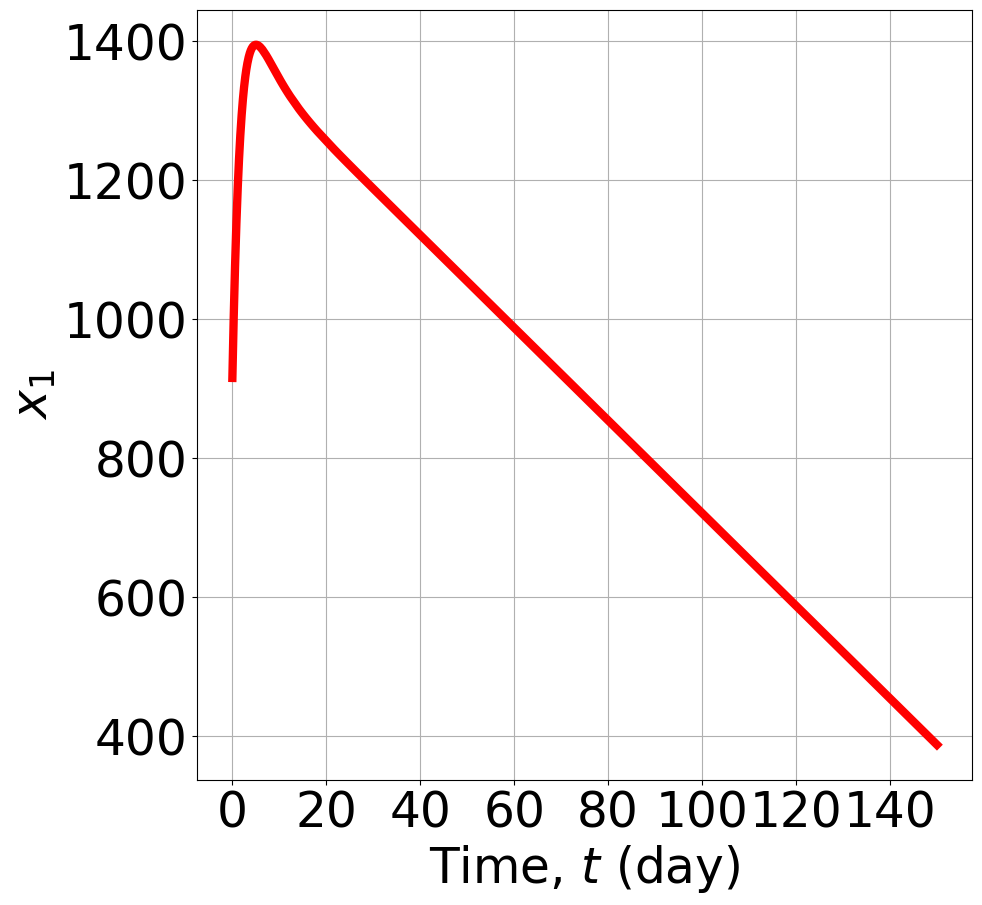

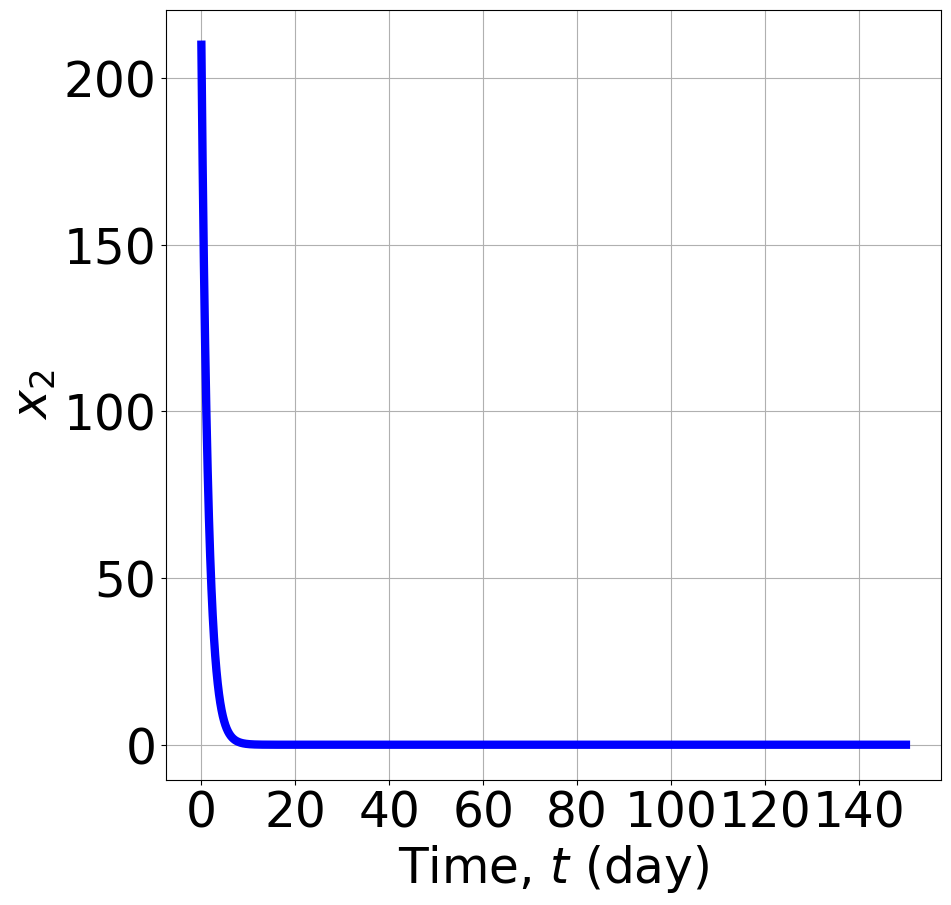

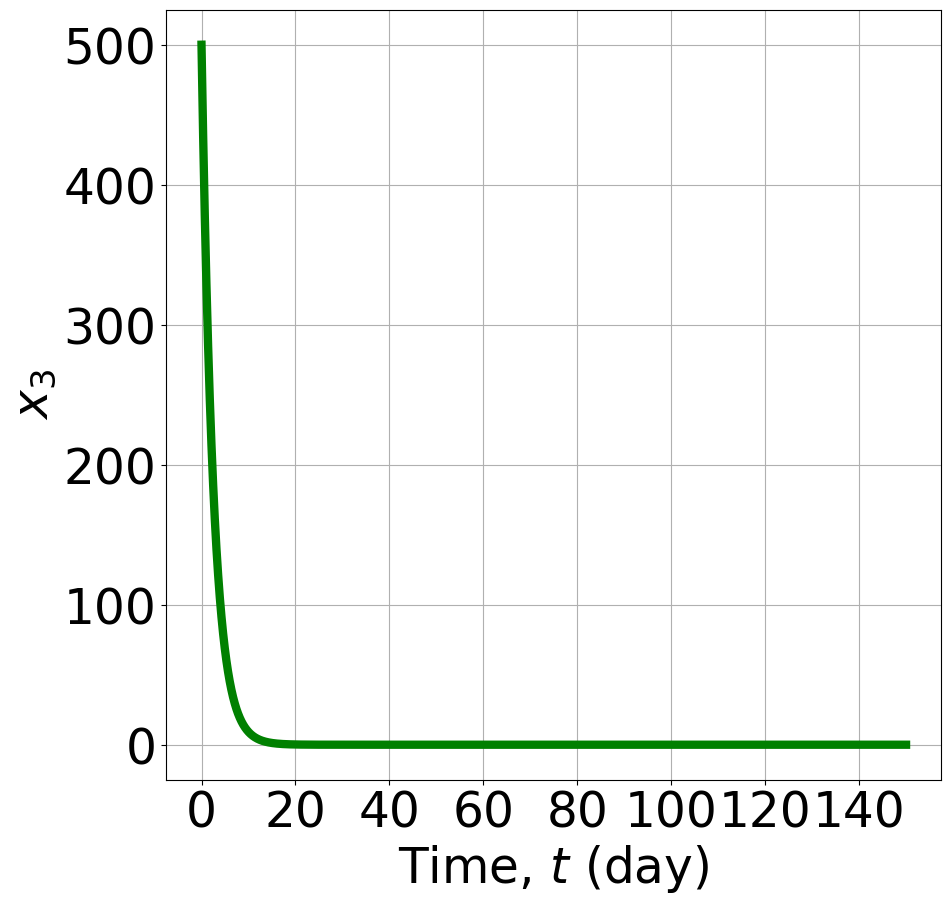

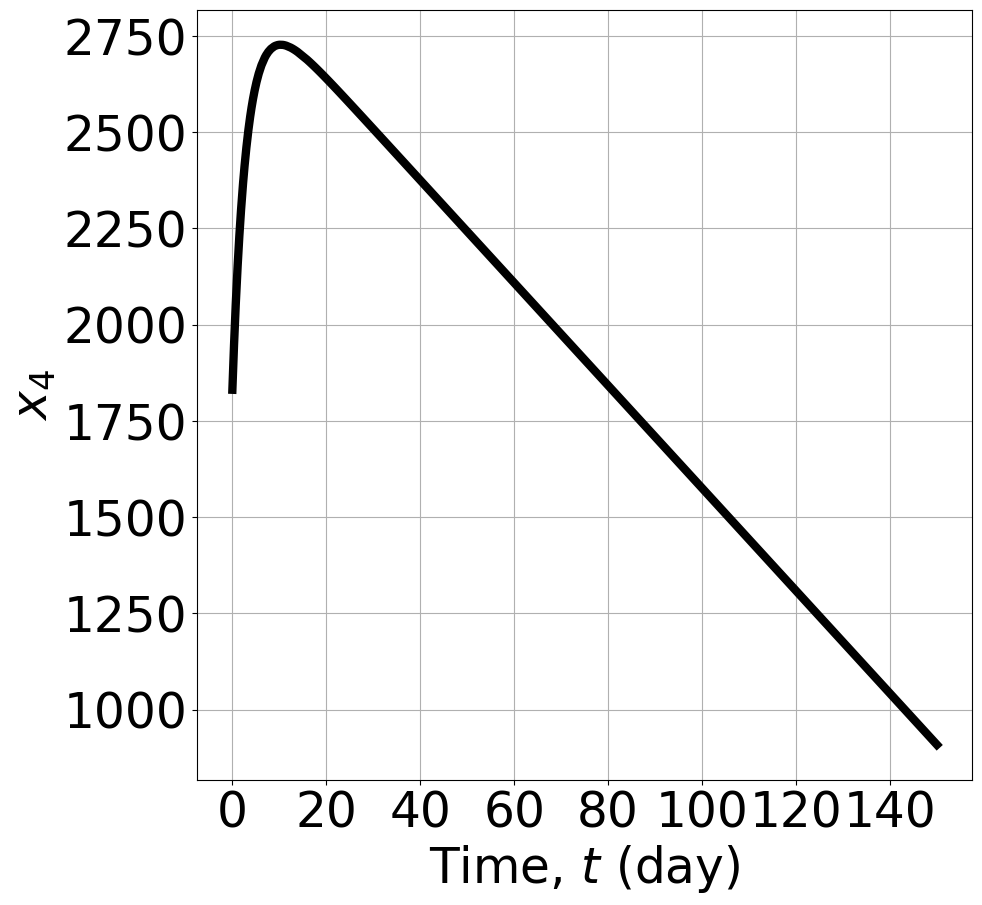

In [ ]:
env = CarboNet()

obs, _ = env.reset()

print(obs)
print(env.observation_space)
print(env.action_space)
#print(env.action_space.sample())

u = 20
u = ((u-env.u_min)/(env.u_max-env.u_min))*(1-(-1))+(-1) # normalize to be in [-1,1] before use
u = [u] # between '[]' because step() expects this shape

n_steps = 3000000

# For plotting:
vector_t = -np.ones(n_steps+1)
vector_x1 = -np.ones(n_steps+1)
vector_x2 = -np.ones(n_steps+1)
vector_x3 = -np.ones(n_steps+1)
vector_x4 = -np.ones(n_steps+1)
vector_t[0] = 0
vector_x1[0] = x1_ini
vector_x2[0] = x2_ini
vector_x3[0] = x3_ini
vector_x4[0] = x4_ini

for step in range(n_steps):
    obs, reward, truncated, terminated, info = env.step(u)

    # For plotting:
    vector_t[step+1] = vector_t[step] + env.dt
    vector_x1[step+1] = obs[0]
    vector_x2[step+1] = obs[1]
    vector_x3[step+1] = obs[2]
    vector_x4[step+1] = obs[3]

env.render()